In [137]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Results Analysis 

This section analyzes the results produced in **Q1–Q3**.

The goal is to identify the best-performing configurations before running the remaining experiments (Q4–Q5),

As well as examine the feature-importance results.

The analysis is performed in two parts:
- **(1) Model Analysis**
- **(2) Feature Analysis**



# Models Results: (1)

We examine the following configuration parameters:
- Models
- Data balancing methods
- Class weights
- Recall optimization

## Load Experiment Results

Load the evaluation results and feature analysis generated during the Q1–Q3 experiments.

In [138]:
results_df = pd.read_csv(
    "out/Q1_3_output.csv",
    keep_default_na=False
)

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 80 rows


,model,balancing,class_weight,threshold_mode,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,KNN,None,None,default,0.998332,1.000000,0.030612,0.059406,0.636393,0.114919,56864,0,95,3
1,KNN,None,None,recall,0.001720,0.001720,1.000000,0.003435,0.636393,0.114919,0,56864,0,98
2,KNN,None,Balanced,default,0.998332,1.000000,0.030612,0.059406,0.636393,0.114919,56864,0,95,3
3,KNN,None,Balanced,recall,0.001720,0.001720,1.000000,0.003435,0.636393,0.114919,0,56864,0,98
4,KNN,Undersampling,None,default,0.651259,0.003317,0.673469,0.006601,0.712692,0.004848,37031,19833,32,66


## Dataset Overview

Inspect the structure of the evaluation results before performing any analysis.

In [139]:
results_df.info()

results_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            80 non-null     str    
 1   balancing        80 non-null     str    
 2   class_weight     80 non-null     str    
 3   threshold_mode   80 non-null     str    
 4   accuracy         80 non-null     float64
 5   precision        80 non-null     float64
 6   recall           80 non-null     float64
 7   f1               80 non-null     float64
 8   roc_auc          80 non-null     float64
 9   pr_auc           80 non-null     float64
 10  true_negatives   80 non-null     int64  
 11  false_positives  80 non-null     int64  
 12  false_negatives  80 non-null     int64  
 13  true_positives   80 non-null     int64  
dtypes: float64(6), int64(4), str(4)
memory usage: 11.5 KB


,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,0.650782,0.135587,0.882908,0.124237,0.905314,0.506814,36983.337500,19880.662500,11.475000,86.525000
std,0.383790,0.295010,0.181261,0.250338,0.111077,0.335423,21869.188138,21869.188138,17.763549,17.763549
min,0.001720,0.001720,0.030612,0.003435,0.636393,0.004848,0.000000,0.000000,0.000000,3.000000
25%,0.374473,0.002706,0.897959,0.005397,0.872237,0.096271,21236.000000,2004.750000,2.750000,88.000000
50%,0.800358,0.008209,0.959184,0.016278,0.968487,0.674230,45496.000000,11368.000000,4.000000,94.000000
75%,0.964665,0.042996,0.971939,0.068131,0.975787,0.743632,54859.250000,35628.000000,10.000000,95.250000
max,0.999596,1.000000,1.000000,0.874317,0.979230,0.874688,56864.000000,56864.000000,95.000000,98.000000


## Best Configuration Analysis

We intend to observe the reuslts and determine which model performed best, and which configuration should we run it with.

The configuration being:
- Data Balancing Method
- Class weight
- Recall Threshold

### Examine Best Performance

We determine the best performance by sorting for Recall, after filtering for Precision >= 0.5 .

Reasoning:
- We're trying to optimize recall while maintaining a reasonable precision
- We noticed that once precision goes below 50% it usually sinks towards the 0~10%

**Conclusion**: Random Forest performed best

In [140]:
best_model_configs = (
    results_df[
        (results_df["precision"] > 0.5)
    ]
    .sort_values("recall", ascending=False)
    .groupby("model")
    .first()
)

best_model_configs[
    [
        "balancing",
        "class_weight",
        "threshold_mode",
        "precision",
        "recall",
        "f1",
        "pr_auc",
        "roc_auc"
    ]
]

,balancing,class_weight,threshold_mode,precision,recall,f1,pr_auc,roc_auc
model,,,,,,,,
AdaBoost,None,None,default,0.705882,0.734694,0.720000,0.724277,0.979230
KNN,None,Balanced,default,1.000000,0.030612,0.059406,0.114919,0.636393
Logistic Regression,None,None,default,0.817073,0.683673,0.744444,0.694752,0.955090
Random Forest,SMOTE_Tomek,Balanced,default,0.831683,0.857143,0.844221,0.873052,0.969262


## Analyzing Our Recall Demand

In fraud detection, missing fraudulent transactions (false negatives) is usually more costly than investigating additional legitimate transactions.

Therefore, we also tried to achieve at least 95% recall, by influencing the model's decision using a costum threshold.

Here we'll examine the configurations that stood up to our expectations, and observe their precision.

**Conclusion**: Our threshold was too high, sinking precisions. Therefore we should not use it from now on.

**Note**: Ideally we would run a lower threshold and try to optimize for 0.9 recall, but due to lack of time we won't do that for all models.

In [141]:
high_recall_models = (
    results_df[
        results_df["recall"] >= 0.95
    ]
    .sort_values(
        ["precision", "pr_auc"],
        ascending=False
    )
    .groupby("model")
    .first()
)

high_recall_models[
    [
        "balancing",
        "class_weight",
        "threshold_mode",
        "precision",
        "recall",
        "f1",
        "pr_auc",
        "roc_auc"
    ]
]

,balancing,class_weight,threshold_mode,precision,recall,f1,pr_auc,roc_auc
model,,,,,,,,
AdaBoost,None,None,recall,0.011106,0.959184,0.021957,0.724277,0.979230
KNN,ClusterCentroids,None,recall,0.001766,0.979592,0.003526,0.008205,0.730227
Logistic Regression,SMOTE,None,recall,0.012648,0.959184,0.024967,0.730241,0.976502
Random Forest,Undersampling,None,recall,0.011229,0.969388,0.022201,0.695286,0.977698


## Effect of Balancing Methods

Class imbalance is a major challenge in fraud detection because fraudulent transactions represent only a small portion of the dataset.

Different balancing techniques are evaluated to determine whether they improve minority-class detection.

The methods compared are:

- **None**: Original imbalanced dataset.
- **SMOTE**: Synthetic generation of minority-class samples.
- **SMOTE-Tomek**: SMOTE combined with Tomek link removal to reduce overlapping samples.
- **Undersampling**: Reduction of majority-class samples.
- **Cluster Centroids**: Majority-class reduction using clustering.

For this comparison, we aggregate results across all models and configurations to observe the general effect of each balancing approach.

## Overall Results   

We can note that overall the balancing did not improve the results, and rather harm them sometimes.

Mostly, the balancing made models improve recall while sinking precision, rendering the balance useless.

Therefore we'll **discuss below** only the entries where both precision and recall are above 0.5 

In [142]:
balancing_effect = results_df[
    (results_df["class_weight"] == "None") &
    (results_df["threshold_mode"] == "default")
]

balancing_effect = balancing_effect[
    [
        "model",
        "balancing",
        "class_weight",
        "precision",
        "recall",
        "f1",
        "pr_auc",
        "roc_auc"
    ]
]

balancing_effect.sort_values(
    ["model", "recall", "precision"],
    ascending=[True, False, False]
)

,model,balancing,class_weight,precision,recall,f1,pr_auc,roc_auc
76,AdaBoost,ClusterCentroids,None,0.002125,0.989796,0.004242,0.040327,0.909416
64,AdaBoost,Undersampling,None,0.031185,0.918367,0.060322,0.641294,0.978860
72,AdaBoost,SMOTE_Tomek,None,0.090349,0.897959,0.164179,0.777023,0.975808
68,AdaBoost,SMOTE,None,0.085854,0.897959,0.156723,0.776375,0.975781
60,AdaBoost,None,None,0.705882,0.734694,0.720000,0.724277,0.979230
16,KNN,ClusterCentroids,None,0.003186,0.775510,0.006345,0.008205,0.730227
4,KNN,Undersampling,None,0.003317,0.673469,0.006601,0.004848,0.712692
12,KNN,SMOTE_Tomek,None,0.016720,0.530612,0.032419,0.029390,0.760699
8,KNN,SMOTE,None,0.016651,0.530612,0.032288,0.029907,0.760055
0,KNN,None,None,1.000000,0.030612,0.059406,0.114919,0.636393


## Balancing Results Conclusion

Filtering by precision and recall over 0.5 shows us that:
- The only benifactor of the balancing methods is **Random Forest**

The addition of data balancing resulted in Random Forest having a better recall,

while sacrificing a bit of it's precision.

Given the sort by recall, we can see that SMOTE_Tomek helped us increase recall to 85% + while maintaining precision above 80%.

**Conclusion**: We'll use Random Forest with SMOTE_Tomek


In [143]:
balancing_effect = results_df[
    (results_df["threshold_mode"] == "default")&
    (results_df["precision"] >= 0.5)&
    (results_df["recall"] >= 0.5)
]

balancing_effect = balancing_effect[
    [
        "model",
        "balancing",
        "class_weight",
        "precision",
        "recall",
        "f1",
        "pr_auc",
        "roc_auc"
    ]
]

balancing_effect.sort_values(
    ["model", "recall", "precision"],
    ascending=[True, False, False]
)

,model,balancing,class_weight,precision,recall,f1,pr_auc,roc_auc
60,AdaBoost,None,None,0.705882,0.734694,0.720000,0.724277,0.979230
62,AdaBoost,None,Balanced,0.705882,0.734694,0.720000,0.724277,0.979230
20,Logistic Regression,None,None,0.817073,0.683673,0.744444,0.694752,0.955090
52,Random Forest,SMOTE_Tomek,None,0.831683,0.857143,0.844221,0.873052,0.969262
54,Random Forest,SMOTE_Tomek,Balanced,0.831683,0.857143,0.844221,0.873052,0.969262
48,Random Forest,SMOTE,None,0.835052,0.826531,0.830769,0.874688,0.964423
50,Random Forest,SMOTE,Balanced,0.835052,0.826531,0.830769,0.874688,0.964423
40,Random Forest,None,None,0.941176,0.816327,0.874317,0.873391,0.963027
42,Random Forest,None,Balanced,0.960526,0.744898,0.839080,0.854200,0.952908


## Effect of Class Weighting

Class weighting modifies the training loss so that mistakes on minority-class samples receive a higher penalty.

Two approaches are compared:

- **None**: All samples contribute equally.
- **Balanced**: The classifier automatically assigns higher importance to fraudulent transactions.
- Note: KNN and Adaboost do not support "class_weight"

The goal is to determine whether weighting the minority class improves fraud detection performance.


-------

We can infer that the class weight was ineffective, as it did not improve the results towards the direction we desired.

For Logistic Regression:
- Improved recall
- Sank Precision (rendering the model useless)

For Random Forest:
- Decreased recall
- Increased precision

**Note**: Class weighting changes the ranking and probability distribution, not necessarily the final classification threshold. Which explains the results.

**Conclusion**: We will not use class_weight feature anymore during our runs


In [144]:
class_weight_effect = results_df[
    (results_df["balancing"] == "None") &
    (results_df["threshold_mode"] == "default") &
    (results_df["model"].isin(["Logistic Regression", "Random Forest"]))
]

class_weight_effect = class_weight_effect[
    [
        "model",
        "class_weight",
        "precision",
        "recall",
        "f1",
        "pr_auc",
        "roc_auc"
    ]
]

class_weight_effect.sort_values(
    ["model", "recall"],
    ascending=[True, False]
)

,model,class_weight,precision,recall,f1,pr_auc,roc_auc
22,Logistic Regression,Balanced,0.045045,0.918367,0.085878,0.732717,0.973966
20,Logistic Regression,None,0.817073,0.683673,0.744444,0.694752,0.955090
40,Random Forest,None,0.941176,0.816327,0.874317,0.873391,0.963027
42,Random Forest,Balanced,0.960526,0.744898,0.839080,0.854200,0.952908


# Final Model-Configuration Conclusions:

1. The best performing model was **Random Forest**, using **SMOTE_Tomek** balancing method
2. **Class weight** and **Recall optimization** turned out to not improve our results
3. Given we only tried to optimized for recall >= 95 , it might be worth to **optimize for a lower recall** to improve results 

----

# Feature Importance Analysis (2)

After evaluating model performance, we analyze feature importance to understand which features contribute most to fraud detection.

We examine three types of importance:

1. **Dataset-level importance**
   - Pearson correlation
   - Spearman correlation
   - Mutual information
   
   These methods measure the relationship between each feature and the target independently of the model.

2. **Model-based importance**
   - Feature importance extracted from the trained model
   - SHAP values

   These methods explain which features influenced the model's predictions.

In [145]:
features_df = pd.read_csv(
    "out/Q1_3_features.csv",
    keep_default_na=False
)

print(f"Feature logs: {len(features_df)} rows")

features_df.head()

Feature logs: 40 rows


,model,balancing,class_weight,pearson_top,spearman_top,mutual_info_top,model_importance_top,shap_importance_top
0,KNN,None,None,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
1,KNN,None,Balanced,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
2,KNN,Undersampling,None,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
3,KNN,Undersampling,Balanced,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
4,KNN,SMOTE,None,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None


In [146]:
features_df[
    [
        "model",
        "balancing",
        "class_weight"
    ]
].drop_duplicates()

features_df.columns

Index(['model', 'balancing', 'class_weight', 'pearson_top', 'spearman_top',
       'mutual_info_top', 'model_importance_top', 'shap_importance_top'],
      dtype='str')

### Parsing Feature Dictionaries

The feature importance values were stored as strings inside the CSV.
We convert them back into dictionaries so they can be analyzed.

In [147]:
dict_columns = [
    "model_importance_top",
    "shap_importance_top",
    "pearson_top",
    "spearman_top",
    "mutual_info_top"
]

for col in dict_columns:
    features_df[col] = features_df[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    
features_df.head()

,model,balancing,class_weight,pearson_top,spearman_top,mutual_info_top,model_importance_top,shap_importance_top
0,KNN,None,None,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
1,KNN,None,Balanced,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
2,KNN,Undersampling,None,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
3,KNN,Undersampling,Balanced,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None
4,KNN,SMOTE,None,"{11: 0.15370859892873284, 4: 0.135013923287937...","{4: 0.06358030267593197, 11: 0.059388996985083...","{'V14': 0.0081352773359461, 'V17': 0.008098974...","{'feature': {0: 'Time', 1: 'V1', 2: 'V2', 3: '...",None


## Dataset-Level Feature Analysis

The following analysis identifies features that show the strongest relationship with the target variable.

- Pearson correlation captures linear relationships.
- Spearman correlation captures monotonic relationships.
- Mutual information captures nonlinear dependencies.

In [148]:
dataset_features = features_df.iloc[0]

pearson = dataset_features["pearson_top"]
spearman = dataset_features["spearman_top"]
mutual_info = dataset_features["mutual_info_top"]

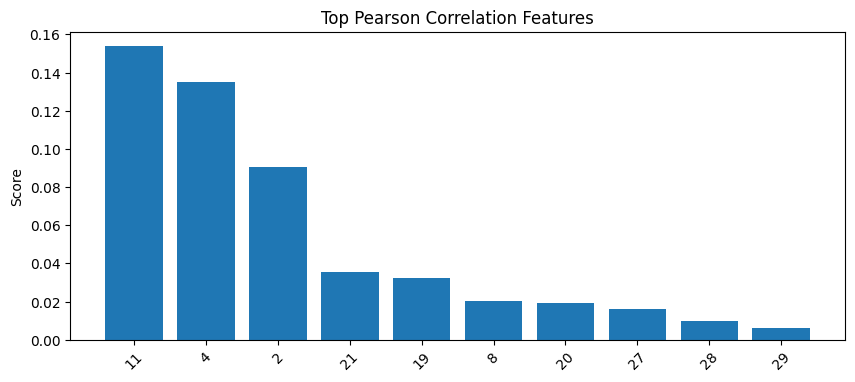

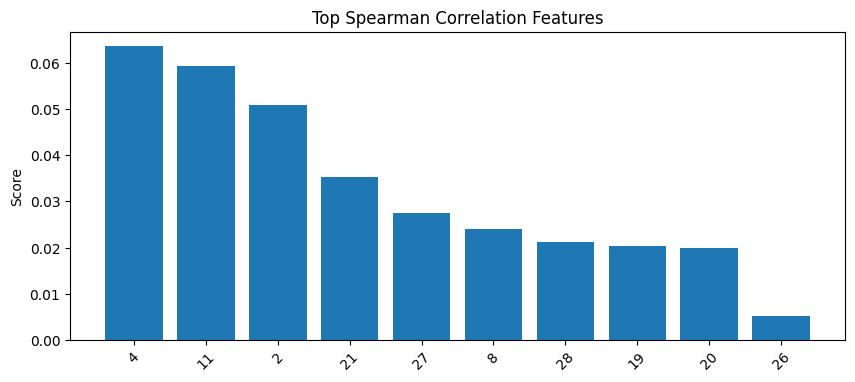

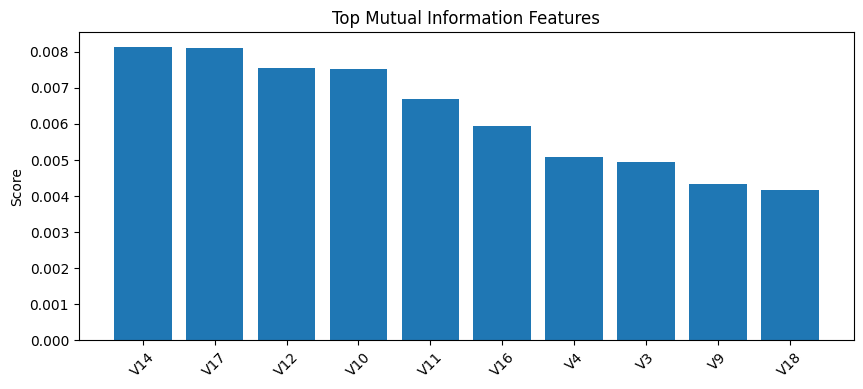

In [149]:
def plot_feature_dict(values, title):
    values = dict(sorted(values.items(), key=lambda x: abs(x[1]), reverse=True))

    plt.figure(figsize=(10,4))
    plt.bar(
        [str(k) for k in values.keys()],
        values.values()
    )
    plt.xticks(rotation=45)
    plt.title(title)
    plt.ylabel("Score")
    plt.show()


plot_feature_dict(
    pearson,
    "Top Pearson Correlation Features"
)

plot_feature_dict(
    spearman,
    "Top Spearman Correlation Features"
)

plot_feature_dict(
    mutual_info,
    "Top Mutual Information Features"
)

| Method | What it measures | Value Range | Interpretation |
|---|---|---|---|
| Pearson Correlation | Linear relationship between a feature and the target | 0.01 - 0.15 | Some features show weak linear association with fraud, but no single feature strongly separates fraud from non-fraud cases |
| Spearman Correlation | Monotonic relationship between a feature and the target | 0.005 - 0.065 | Features have limited ordered relationships with fraud probability |
| Mutual Information | General dependency, including nonlinear relationships | 0.005 - 0.008 | Individual features provide limited information gain; fraud prediction likely depends on feature combinations |

### Data-Level Feature Analysis Conclusion

The low correlation and dependency scores across all methods indicate that no individual feature has a strong linear or monotonic relationship with fraud transactions. This suggests that fraud detection likely depends on complex feature interactions rather than a small subset of highly correlated features.

## Model-Level Feature Analysis

While correlation-based analysis evaluates features independently, model-level analysis examines which features contribute most to the predictions made by trained models. This allows us to capture feature interactions and understand the decision-making process of the selected models.

### **Logistic Regression** Feature Analysis

Logistic Regression assigns a coefficient to each feature, representing its influence on the prediction. Positive coefficients increase the likelihood of a transaction being classified as fraud, while negative coefficients decrease it.

In [150]:
lr_features = features_df[
    (features_df["model"] == "Logistic Regression") &
    (features_df["balancing"] == "None") &
    (features_df["class_weight"] == "None")
]

lr_features[
    [
        "model",
        "balancing",
        "class_weight",
        "model_importance_top",
        "shap_importance_top"
    ]
]

lr_model_importance = lr_features.iloc[0]["model_importance_top"]

lr_coef_df = pd.DataFrame({
    "feature": list(lr_model_importance["feature"].values()),
    "coefficient": list(lr_model_importance["importance"].values())
})

# Rank by absolute coefficient magnitude
lr_coef_df["abs_coefficient"] = lr_coef_df["coefficient"].abs()

lr_coef_df = lr_coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

lr_coef_df

,feature,coefficient,abs_coefficient
0,V25,1.101562,1.101562
1,V15,0.894214,0.894214
2,V14,0.832868,0.832868
3,V22,0.825691,0.825691
4,V21,0.709064,0.709064
5,V4,0.689635,0.689635
6,V3,0.588369,0.588369
7,V10,0.585287,0.585287
8,V11,0.556102,0.556102
9,V13,0.545941,0.545941


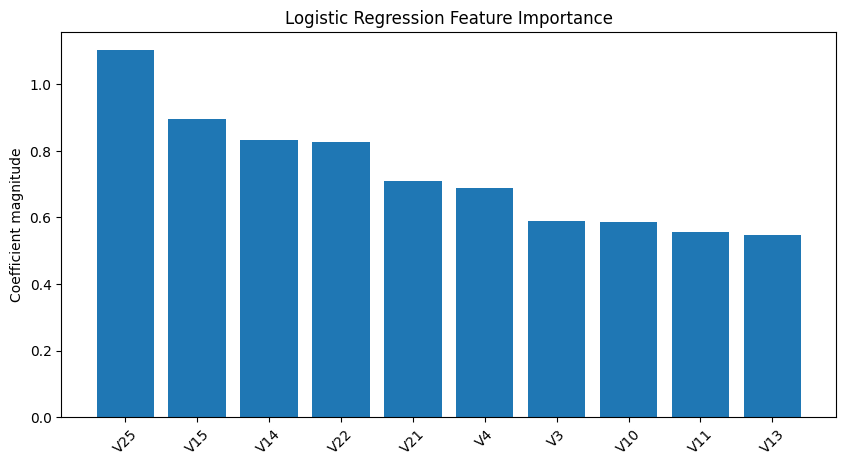

In [151]:
plt.figure(figsize=(10,5))

plt.bar(
    lr_coef_df["feature"],
    lr_coef_df["coefficient"]
)

plt.xticks(rotation=45)
plt.ylabel("Coefficient magnitude")
plt.title("Logistic Regression Feature Importance")

plt.show()

### SHAP Feature Importance

SHAP analysis identifies the features with the largest contribution to Logistic Regression predictions.  
The most influential features were `Time`, `V4`, and `V3`, indicating their higher impact on model decisions.

Model coefficients represent the direct contribution of each feature to the Logistic Regression decision boundary, while SHAP values explain the contribution of each feature to individual predictions.  
SHAP was used to complement coefficient analysis by providing a more interpretable view of feature impact on the model's outputs.

In [152]:
lr_shap_importance = lr_features.iloc[0]["shap_importance_top"]

lr_shap_df = pd.DataFrame({
    "feature": list(lr_shap_importance["feature"].values()),
    "shap_importance": list(lr_shap_importance["shap_importance"].values())
})

lr_shap_df = lr_shap_df.sort_values(
    "shap_importance",
    ascending=False
)

lr_shap_df

,feature,shap_importance
0,Time,1.532586
1,V4,0.736789
2,V3,0.678049
3,V15,0.649184
4,V14,0.547835
5,V22,0.484601
6,V11,0.467064
7,V25,0.444634
8,V13,0.427756
9,V10,0.411471


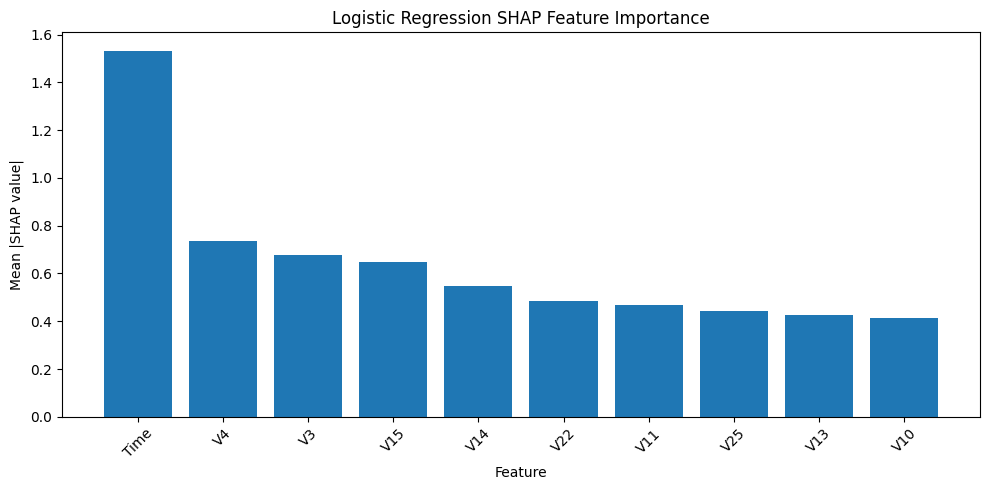

In [153]:
# Plot SHAP feature importance
plt.figure(figsize=(10, 5))

plt.bar(
    lr_shap_df["feature"],
    lr_shap_df["shap_importance"]
)

plt.xlabel("Feature")
plt.ylabel("Mean |SHAP value|")
plt.title("Logistic Regression SHAP Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Conclusions:

Logistic Regression coefficients identified V25, V15, V14, and V22 as the features with the strongest global influence on the model's decision boundary. SHAP analysis complemented this by showing which features contributed most to actual predictions, highlighting Time, V4, V3, and V15 as important drivers of model decisions.

----

## **Random Forest** Feature Analysis

Random Forest evaluates feature importance based on how much each feature contributes to improving the model's decisions across multiple decision trees. Unlike Logistic Regression coefficients, feature importance in Random Forest does not represent a direct positive or negative relationship with fraud, but rather the overall contribution of each feature to the model's predictive performance.

In [154]:
rf_features = features_df[
    (features_df["model"] == "Random Forest") &
    (features_df["balancing"] == "None") &
    (features_df["class_weight"] == "None")
]

rf_features[
    [
        "model",
        "balancing",
        "class_weight",
        "model_importance_top",
        "shap_importance_top"
    ]
]

rf_model_importance = rf_features.iloc[0]["model_importance_top"]

rf_importance_df = pd.DataFrame({
    "feature": list(rf_model_importance["feature"].values()),
    "importance": list(rf_model_importance["importance"].values())
})

rf_importance_df = rf_importance_df.sort_values(
    "importance",
    ascending=False
)

rf_importance_df

,feature,importance
0,V17,0.170325
1,V14,0.136363
2,V12,0.133326
3,V10,0.074073
4,V16,0.071792
5,V11,0.045277
6,V9,0.031127
7,V4,0.030496
8,V18,0.028156
9,V7,0.024627


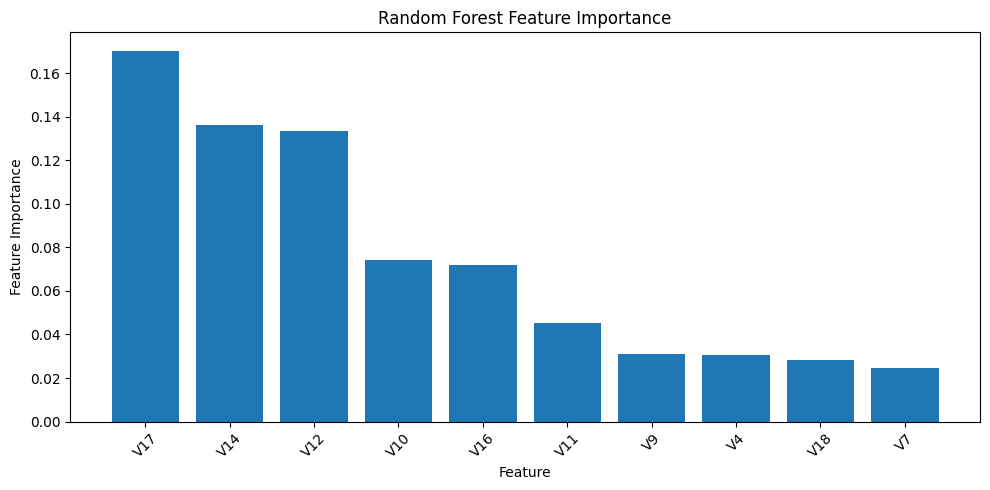

In [155]:
plt.figure(figsize=(10, 5))

plt.bar(
    rf_importance_df["feature"],
    rf_importance_df["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Conclusions:

Random Forest identified V17, V14, and V12 as the most important features based on their contribution to tree-based decisions. Since the importance is distributed across multiple features rather than concentrated in a few variables, the model likely relies on complex feature interactions when making predictions.

**Note**: We lost Random Forest's SHAP values during the run. We MAY run it again specifically on Random Forest later, though that data is missing for now.

---



# Final Conclusions Feature Analysis (2)

1. The **correlation analysis** indicates that there are **no strong direct relationships** between individual features and the transaction class, suggesting that fraud detection depends on more complex patterns rather than single-feature effects.

2. **Logistic Regression coefficient analysis** shows that features **V25, V15, V14, and V22** have the strongest influence on the model's global decision boundary.

3. **Logistic Regression SHAP analysis** provides local explanations of predictions and highlights that **Time** has the largest contribution to individual predictions, followed by **V4 and V3**.

4. **Random Forest feature importance** shows that features such as **V17, V14, and V12** contribute most to tree decisions. However, the distributed importance across multiple features suggests that Random Forest likely captures complex feature interactions rather than relying on a small number of dominant predictors.

**Note:** Given that Random Forest is our best performing model, it would be interesting to run SHAP's TreeExplainer on it specifically as well as observe how these results may vary using different data-balancing methods